In [2]:
import sys
sys.path.append("../src")

from brisc_project.brisc import get_data_loader

In [12]:
train_loader, classes = get_data_loader(
    r"C:\Users\ccai2\Downloads\brain_tumor\brisc2025\classification_task\train",
    batch_size=32
)

test_loader, _ = get_data_loader(
    r"C:\Users\ccai2\Downloads\brain_tumor\brisc2025\classification_task\test",
    batch_size=32
)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(classes)

torch.Size([32, 3, 224, 224])
torch.Size([32])
['glioma', 'meningioma', 'no_tumor', 'pituitary']


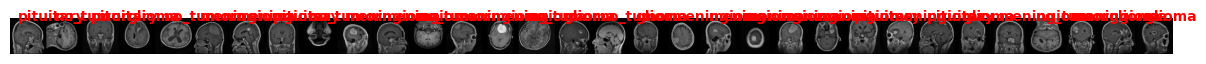

In [14]:
from matplotlib import pyplot as plt
import numpy as np

plot_images = images.numpy().transpose(0, 2, 3, 1)

plt.figure(figsize=(15,5))
plt.imshow(np.hstack(plot_images))

for index, label in enumerate(labels):
    plt.text(
        index * 224 + 50,
        20,
        classes[label.item()],
        color="red",
        fontsize=10,
        fontweight="bold"
    )

plt.axis("off")
plt.show()

In [15]:
import torch
import torch.nn as nn
import torchvision.models as models

num_classes = len(classes)

model = models.resnet18(weights="DEFAULT")

model.fc = nn.Linear(model.fc.in_features, num_classes)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Using device:", device)

Using device: cpu


In [17]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = correct / total

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {running_loss:.4f}")
    print(f"Training Accuracy: {accuracy:.4f}")

Epoch 1/3
Loss: 52.4506
Training Accuracy: 0.8828
Epoch 2/3
Loss: 24.0324
Training Accuracy: 0.9456
Epoch 3/3
Loss: 20.9853
Training Accuracy: 0.9540


In [18]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", correct / total)

Test Accuracy: 0.962


In [19]:
torch.save(model.state_dict(), "resnet18_brain_tumor.pth")

In [20]:
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [21]:
print("Training images:", len(train_loader.dataset))
print("Testing images:", len(test_loader.dataset))

Training images: 5000
Testing images: 1000


In [22]:
from collections import Counter

labels = train_loader.dataset.targets

for class_id, count in Counter(labels).items():
    print(classes[class_id], count)

glioma 1147
meningioma 1329
no_tumor 1067
pituitary 1457


In [23]:
print(model.fc)

Linear(in_features=512, out_features=4, bias=True)


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Using device:", device)

Using device: cpu


In [27]:
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {running_loss:.4f}")
    print(f"Training Accuracy: {correct / total:.4f}")

Epoch 1/3
Loss: 21.7575
Training Accuracy: 0.9520
Epoch 2/3
Loss: 8.6352
Training Accuracy: 0.9812
Epoch 3/3
Loss: 13.3833
Training Accuracy: 0.9698


In [28]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", correct / total)

Test Accuracy: 0.942


In [29]:
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.99      0.91      0.94       254
  meningioma       0.94      0.90      0.91       306
    no_tumor       0.93      0.99      0.96       140
   pituitary       0.92      1.00      0.96       300

    accuracy                           0.94      1000
   macro avg       0.94      0.95      0.94      1000
weighted avg       0.94      0.94      0.94      1000



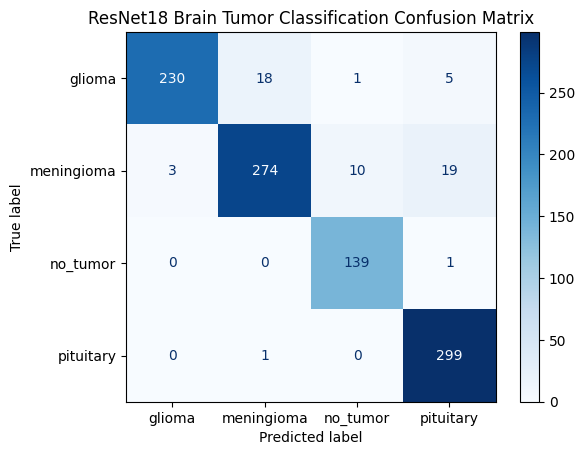

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap="Blues")
plt.title("ResNet18 Brain Tumor Classification Confusion Matrix")
plt.show()

In [31]:
torch.save(model.state_dict(), "resnet18_brain_tumor.pth")